In [ ]:
import os
import io
import math
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
from PIL import Image
import cv2
from google.colab import drive

In [ ]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
def add_pepper(img_bin: np.ndarray, amount: float, seed: int | None = None) -> np.ndarray:
    """
    Add black pixel (pepper) to a binary image.
    img_bin: binary array {0,1} o {0,255}, 2D.
    amount: fraction of pixels to convert (0 -> 1.0).
    """
    noisy = img_bin.copy()
    h, w = noisy.shape[:2]
    total = h * w
    k = int(round(amount * total))
    if k == 0:
        return noisy

    rng = np.random.default_rng(seed)
    idx = rng.choice(total, size=k, replace=False)

    black = 0
    noisy.flat[idx] = black
    return noisy

In [ ]:
def rasterize_segments(segments, img_size=(515, 389)):
    '''
    Given the coordinates, it creates a binary image of specific dimensions.
    '''
    fig, ax = plt.subplots(figsize=(img_size[0]/100, img_size[1]/100), dpi=100)
    ax.set_axis_off()
    ax.set_aspect('equal', adjustable='box')

    # Calculate global bounding box for all segments to normalize scaling
    all_coords = np.vstack(segments)
    min_x, max_x = all_coords[:, 0].min(), all_coords[:, 0].max()
    min_y, max_y = all_coords[:, 1].min(), all_coords[:, 1].max()

    # Adjust plot limits to fit all segments tightly
    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)

    for seg in segments:
        if len(seg) > 1:
            ax.plot(seg[:,0], seg[:,1], color='black', linewidth=1)

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # Render the figure to a buffer
    fig.canvas.draw()
    img_rgba = np.array(fig.canvas.renderer.buffer_rgba())
    plt.close(fig)

    # I delete the figure to avoid memory saturation
    del fig, ax
    if np.random.randint(0, 100) == 0:
      gc.collect()

    # Convert RGBA to grayscale
    img = Image.fromarray(img_rgba).convert("L")
    img = img.resize(img_size, Image.LANCZOS)

    # Binarize the image
    img = img.point(lambda p: 255 if p > 128 else 0)

    return np.array(img)

In [ ]:
def Image_Loader(dataframe, range_0, range_length, k):
   '''
   This function gives as output the set of images that will be evaluated and their respective fractal dimension (label) as np arrays
   '''

   eval_set = []
   label = []

   for i in range(range_0,range_length):

      fname = dataframe["Percorso_Coordinate"][i]
      Fdim = dataframe["Dimensione_Frattale"][i]
      coords = np.load(fname)

      threshold = 200

      img = rasterize_segments([coords], img_size=(515, 389))

      img1 = np.array(img)

      scelta=[0.0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2]

      tipo = scelta[k]
      img2 = add_pepper(img1, amount=tipo)

      img3 = (img2 > threshold).astype(np.float32)

      image = img3[:, :, np.newaxis]

      eval_set.append(image)
      FDim_label.append(Fdim)

   eval_set = np.asarray(eval_set)
   label = np.array(label)

   return eval_set, label

Carico le immagini per il test

In [ ]:
drive_base = "/content/drive/My Drive/coord"
local_base = "/content/dataset"
os.makedirs(local_base, exist_ok=True)

def upload_modify_csv(path_csv, fil):
    df = pd.read_csv(path_csv)
    df["Percorso_Coordinate"] = df["Percorso_Coordinate"].str.replace(
        f"/content/drive/My Drive/{fil}/",
        f"/content/dataset/{fil}/{fil}/"
    )
    return df

# List of files
folder = [f"DATASET-{i}" for i in range(1,8)]


# Extract the ZIP files locally
for fil in folder:
    zip_path = os.path.join(drive_base, f"{fil}.zip")
    estrai_in = os.path.join(local_base, fil)
    if os.path.exists(zip_path) and not os.path.exists(estrai_in):
        os.makedirs(estrai_in, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(estrai_in)
        print(f"Extract: {fil}.zip")

# Uploading and modifing the original CSV

df_gruops = []
for idx in range(1,8):
    group = [
        f"DATASET-{idx}"
    ]
    df_list = []
    for fil in group:
        path_csv = os.path.join(local_base, fil, fil, "a_etichette.csv")
        if os.path.exists(path_csv):
            df_modificato = upload_modify_csv(path_csv, fil)
            df_list.append(df_modificato)
    if df_list:
     df_group = pd.concat(df_list, ignore_index=True)
     df_gruops.append(df_group)
    else:
     print(f"No CSV found for this group {idx}")

# Putting everything togheter

df = pd.concat(df_gruops, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

# Dividing the dataset in local training + (validation + test) CSV files

train_size = 0.71429
val_size = 0.142855
test_size = 0.142855

train_dff, df_temp = train_test_split(df, test_size=(1 - train_size), random_state=300)

val_dff, test_dff = train_test_split(df_temp, test_size=(test_size / (val_size + test_size)), random_state=300)

train_dff.to_csv("/content/train_df_local.csv", index=False)

val_dff.to_csv("/content/val_df_local.csv", index=False)

test_dff.to_csv("/content/test_df_local.csv", index=False)

#  Final Sets

train_df = pd.read_csv("/content/train_df_local.csv")
val_df = pd.read_csv("/content/val_df_local.csv")
test_df = pd.read_csv("/content/test_df_local.csv")

Mounted at /content/drive
✅ Estratto: DATASET-1.zip
✅ Estratto: DATASET-2.zip
✅ Estratto: DATASET-3.zip
✅ Estratto: DATASET-4.zip
✅ Estratto: DATASET-5.zip
✅ Estratto: DATASET-6.zip
✅ Estratto: DATASET-7.zip
15000 3000 3000


Risultati del Test

In [ ]:
ms = '/content/drive/My Drive/Modelli/Coordinate2/AlexNet_model.keras'
model = load_model(ms)

for k in range(9):
  test_images, FDim_label = Image_Loader(test_df, 0, int(len(test_df)), k)
  predicted_values = model.predict(test_images).flatten()
  errors = ((predicted_values - FDim_label) / FDim_label) * 100

  col_name = f"Errore_{k}"
  test_df[col_name] = errors

94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 133ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step


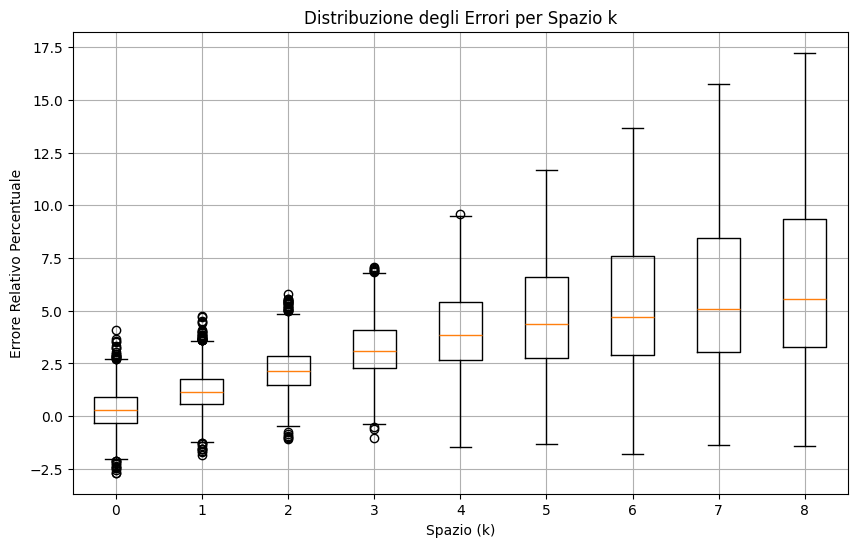

In [ ]:
%matplotlib inline

# Visualization of the errors

cols = [f"Error_{k}" for k in range(9)]

data = [test_df[col].dropna().values for col in cols]

plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=[str(k) for k in range(9)], showfliers=True)

plt.xlabel("Percentage of Noise")
plt.ylabel("Relative Percentage Error")
plt.title("Distributions of Errors Given Noise")
plt.grid(True)
plt.show()

In [ ]:
# Upload the results to a drive folder

drive.mount('/content/drive')

result_dir = '/content/drive/MyDrive/Results'
os.makedirs(result_dir, exist_ok=True)

csv_path = os.path.join(result_dir, 'dimensioni_frattali.csv')
test_df.to_csv(csv_path, index_label='Indice')

print(f"CSV path: {csv_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ CSV salvato in: /content/drive/MyDrive/RisultatiReteNoiseNoAug/dimensioni_frattali.csv
